<a href="https://colab.research.google.com/github/Dnyamwamu/neural_nets/blob/main/Notebooks/Chap10/10_4_Downsampling_and_Upsampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 10.4: Downsampling and Upsampling**

This notebook investigates the upsampling and downsampling methods discussed in section 10.4 of the book.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numpy import asarray

In [2]:
# Define 4 by 4 original patch
orig_4_4 = np.array([[1, 3, 5,3 ], [6,2,0,8], [4,6,1,4], [2,8,0,3]])
print(orig_4_4)

[[1 3 5 3]
 [6 2 0 8]
 [4 6 1 4]
 [2 8 0 3]]


In [3]:
import numpy as np

# Example input
x_in = np.array([[1, 3, 5, 3],
                 [6, 2, 0, 8],
                 [4, 6, 1, 4],
                 [2, 8, 0, 3]])

def downsample(x_in):
    # Determine output shape
    out_rows = int(np.ceil(x_in.shape[0]/2))
    out_cols = int(np.ceil(x_in.shape[1]/2))
    x_out = np.zeros((out_rows, out_cols))

    # Loop over 2x2 blocks
    for i in range(out_rows):
        for j in range(out_cols):
            # Determine the slice in the input
            block = x_in[2*i : 2*i+2, 2*j : 2*j+2]
            # Take the mean of the block
            x_out[i,j] = np.mean(block)

    return x_out

# Test
x_down = downsample(x_in)
print(x_down)

[[3. 4.]
 [5. 2.]]


In [ ]:
print("Original:")
print(orig_4_4)
print("Downsampled:")
print(downsample(orig_4_4))

Let's try that on an image to get a feel for how it works:

In [5]:
!wget https://raw.githubusercontent.com/udlbook/udlbook/main/Notebooks/Chap10/test_image.png

--2026-03-06 19:04:13--  https://raw.githubusercontent.com/udlbook/udlbook/main/Notebooks/Chap10/test_image.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60792 (59K) [image/png]
Saving to: ‘test_image.png’

test_image.png      100%[===================>]  59.37K  --.-KB/s    in 0.008s  

2026-03-06 19:04:13 (7.52 MB/s) - ‘test_image.png’ saved [60792/60792]



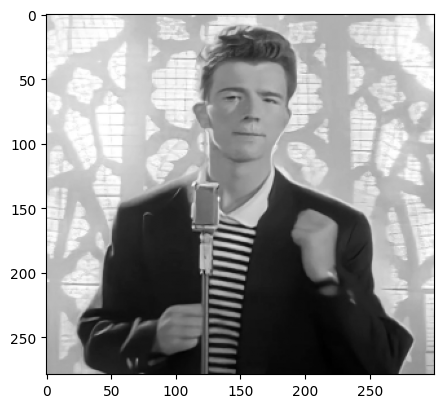

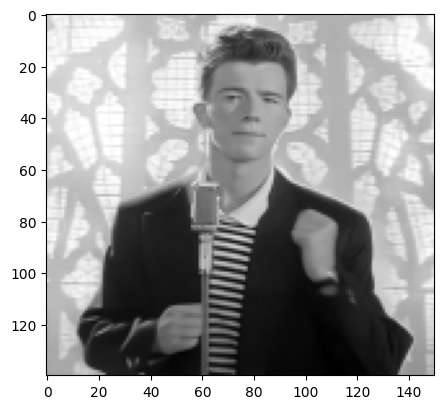

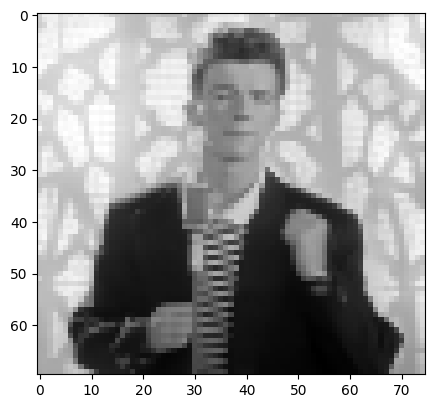

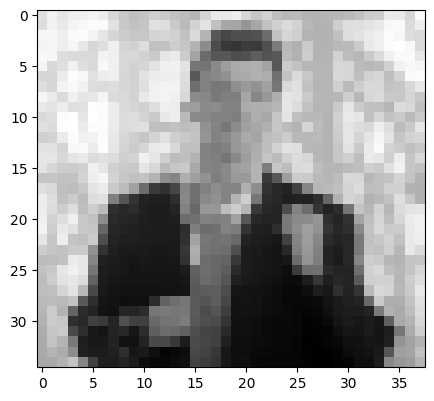

In [6]:
# load the image
image = Image.open('test_image.png')
# convert image to numpy array
data = asarray(image)
data_downsample = downsample(data);

plt.figure(figsize=(5,5))
plt.imshow(data, cmap='gray')
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(data_downsample, cmap='gray')
plt.show()

data_downsample2 = downsample(data_downsample)
plt.figure(figsize=(5,5))
plt.imshow(data_downsample2, cmap='gray')
plt.show()

data_downsample3 = downsample(data_downsample2)
plt.figure(figsize=(5,5))
plt.imshow(data_downsample3, cmap='gray')
plt.show()

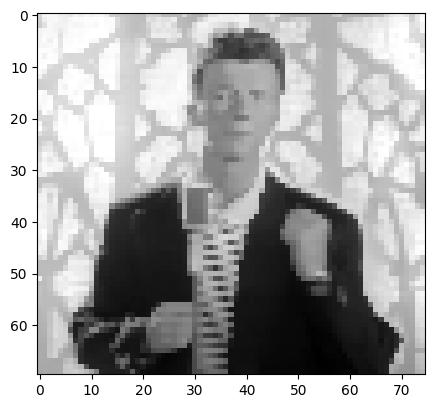

In [7]:
import numpy as np

def maxpool(x_in):
    # Determine output shape
    out_rows = int(np.floor(x_in.shape[0]/2))
    out_cols = int(np.floor(x_in.shape[1]/2))
    x_out = np.zeros((out_rows, out_cols))

    # Loop over 2x2 blocks
    for i in range(out_rows):
        for j in range(out_cols):
            block = x_in[2*i : 2*i+2, 2*j : 2*j+2]
            x_out[i,j] = np.max(block)

    return x_out

# Example test with your previous downsampled data
data_maxpooled = maxpool(data_downsample)
plt.figure(figsize=(5,5))
plt.imshow(data_maxpooled, cmap='gray')
plt.show()

In [8]:
print("Original:")
print(orig_4_4)
print("Maxpooled:")
print(maxpool(orig_4_4))

Original:
[[1 3 5 3]
 [6 2 0 8]
 [4 6 1 4]
 [2 8 0 3]]
Maxpooled:
[[6. 8.]
 [8. 4.]]


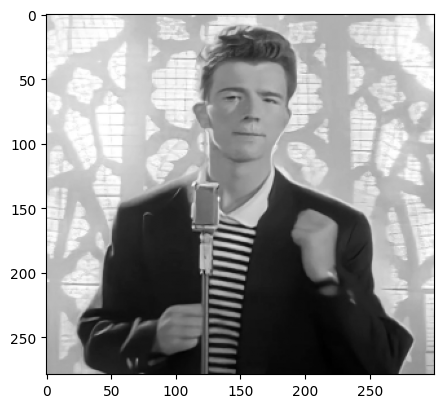

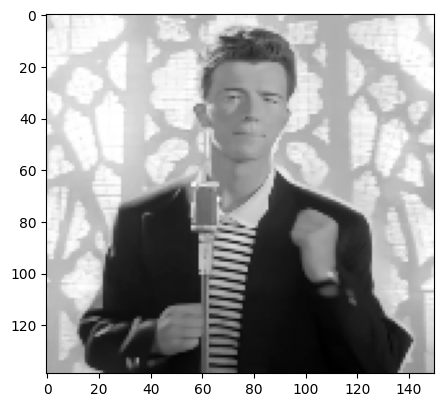

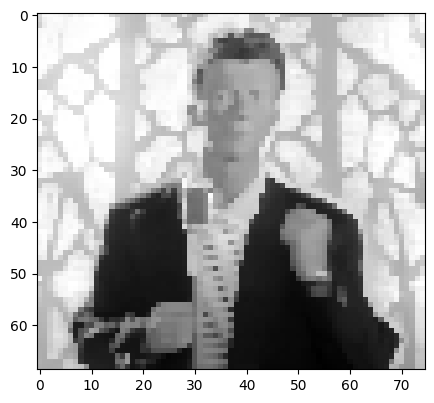

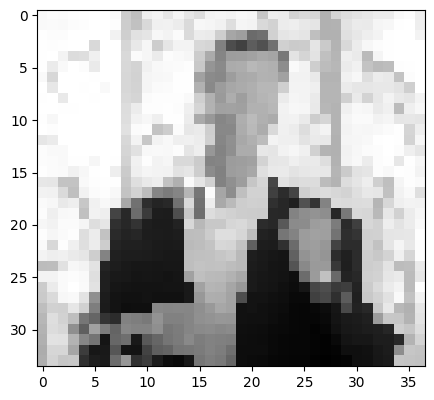

In [9]:
# Let's see what Rick looks like:
data_maxpool = maxpool(data);

plt.figure(figsize=(5,5))
plt.imshow(data, cmap='gray')
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(data_maxpool, cmap='gray')
plt.show()

data_maxpool2 = maxpool(data_maxpool)
plt.figure(figsize=(5,5))
plt.imshow(data_maxpool2, cmap='gray')
plt.show()

data_maxpool3 = maxpool(data_maxpool2)
plt.figure(figsize=(5,5))
plt.imshow(data_maxpool3, cmap='gray')
plt.show()

You can see that the stripes on his shirt gradually turn to white because we keep retaining the brightest local pixels.

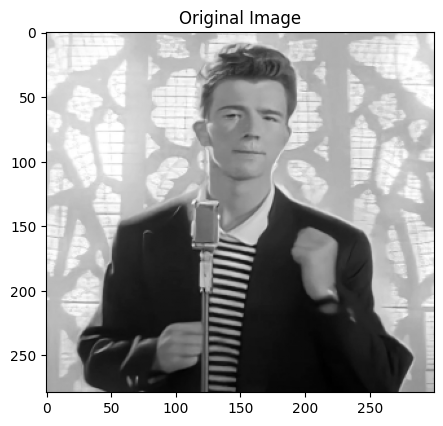

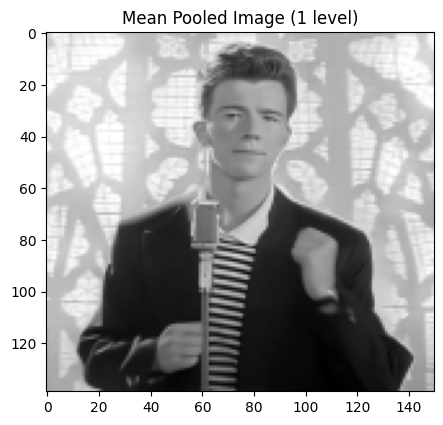

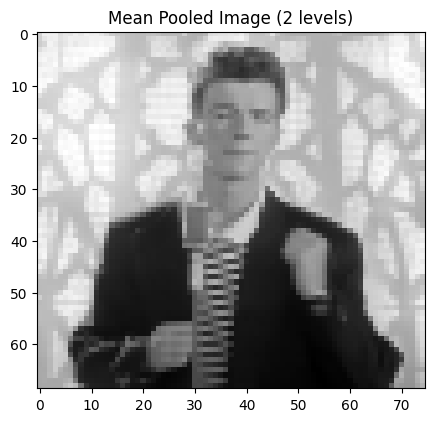

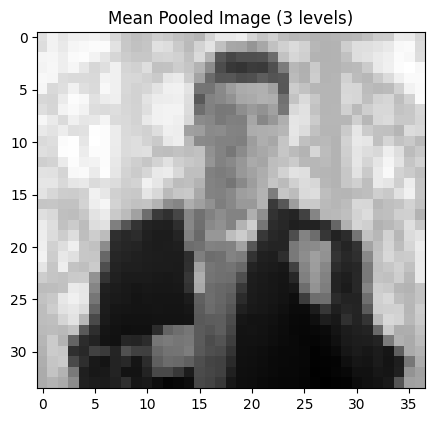

In [10]:
import numpy as np

def meanpool(x_in):
    # Determine output shape
    out_rows = int(np.floor(x_in.shape[0]/2))
    out_cols = int(np.floor(x_in.shape[1]/2))
    x_out = np.zeros((out_rows, out_cols))

    # Loop over 2x2 blocks
    for i in range(out_rows):
        for j in range(out_cols):
            block = x_in[2*i : 2*i+2, 2*j : 2*j+2]
            x_out[i,j] = np.mean(block)

    return x_out

# Example: Apply mean pooling to your data
data_meanpool = meanpool(data)

plt.figure(figsize=(5,5))
plt.imshow(data, cmap='gray')
plt.title("Original Image")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(data_meanpool, cmap='gray')
plt.title("Mean Pooled Image (1 level)")
plt.show()

# Apply multiple levels
data_meanpool2 = meanpool(data_meanpool)
plt.figure(figsize=(5,5))
plt.imshow(data_meanpool2, cmap='gray')
plt.title("Mean Pooled Image (2 levels)")
plt.show()

data_meanpool3 = meanpool(data_meanpool2)
plt.figure(figsize=(5,5))
plt.imshow(data_meanpool3, cmap='gray')
plt.title("Mean Pooled Image (3 levels)")
plt.show()

In [11]:
print("Original:")
print(orig_4_4)
print("Meanpooled:")
print(meanpool(orig_4_4))

Original:
[[1 3 5 3]
 [6 2 0 8]
 [4 6 1 4]
 [2 8 0 3]]
Meanpooled:
[[3. 4.]
 [5. 2.]]


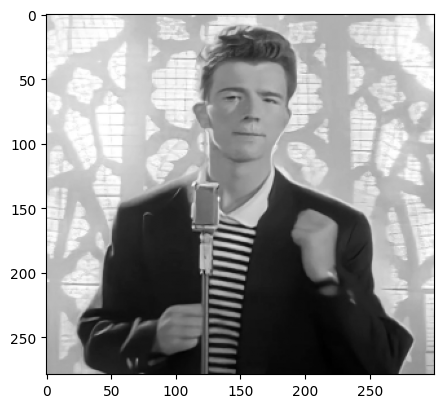

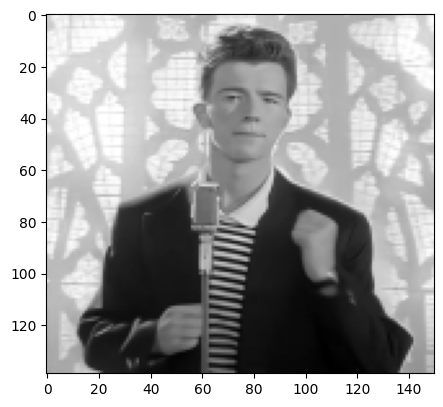

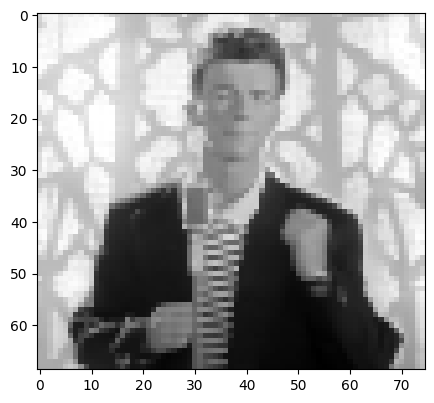

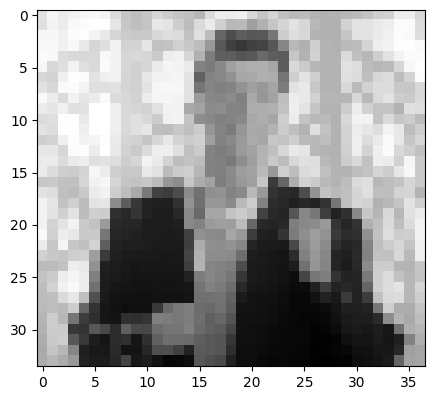

In [12]:
# Let's see what Rick looks like:
data_meanpool = meanpool(data);

plt.figure(figsize=(5,5))
plt.imshow(data, cmap='gray')
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(data_meanpool, cmap='gray')
plt.show()

data_meanpool2 = meanpool(data_maxpool)
plt.figure(figsize=(5,5))
plt.imshow(data_meanpool2, cmap='gray')
plt.show()

data_meanpool3 = meanpool(data_meanpool2)
plt.figure(figsize=(5,5))
plt.imshow(data_meanpool3, cmap='gray')
plt.show()

Notice that the three low resolution images look quite different. <br>

Now let's upscale them again

In [13]:
# Define 2 by 2 original patch
orig_2_2 = np.array([[6, 8], [8,4]])
print(orig_2_2)

[[6 8]
 [8 4]]


In [14]:
# Let's first use the duplication method


def duplicate(x_in):
    # Determine output shape
    out_rows = x_in.shape[0] * 2
    out_cols = x_in.shape[1] * 2
    x_out = np.zeros((out_rows, out_cols))

    # Loop over each element and duplicate it
    for i in range(x_in.shape[0]):
        for j in range(x_in.shape[1]):
            x_out[2*i:2*i+2, 2*j:2*j+2] = x_in[i,j]

    return x_out

# Test with your 2x2 patch
orig_2_2 = np.array([[6, 8], [8,4]])
dup_patch = duplicate(orig_2_2)
print("Duplicated patch:\n", dup_patch)

Duplicated patch:
 [[6. 6. 8. 8.]
 [6. 6. 8. 8.]
 [8. 8. 4. 4.]
 [8. 8. 4. 4.]]


In [15]:
print("Original:")
print(orig_2_2)
print("Duplicated:")
print(duplicate(orig_2_2))

Original:
[[6 8]
 [8 4]]
Duplicated:
[[6. 6. 8. 8.]
 [6. 6. 8. 8.]
 [8. 8. 4. 4.]
 [8. 8. 4. 4.]]


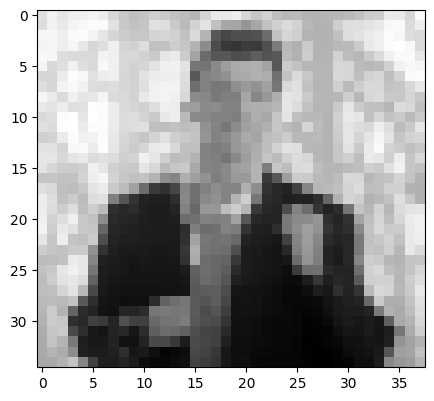

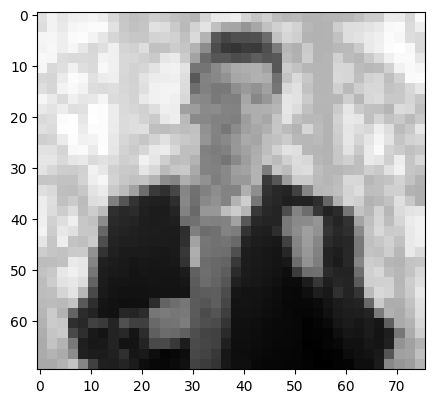

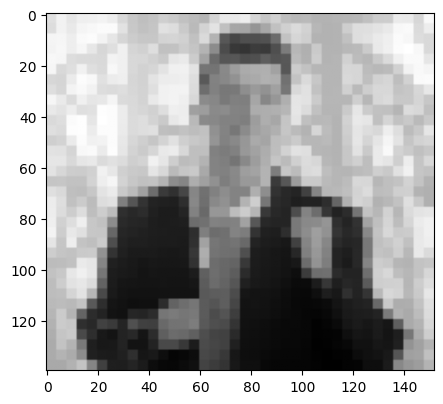

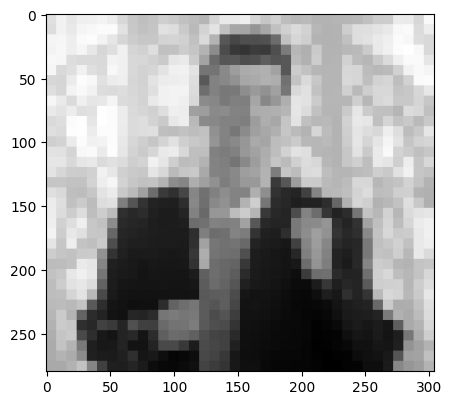

In [16]:
# Let's re-upsample, downsampled rick
data_duplicate = duplicate(data_downsample3);

plt.figure(figsize=(5,5))
plt.imshow(data_downsample3, cmap='gray')
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(data_duplicate, cmap='gray')
plt.show()

data_duplicate2 = duplicate(data_duplicate)
plt.figure(figsize=(5,5))
plt.imshow(data_duplicate2, cmap='gray')
plt.show()

data_duplicate3 = duplicate(data_duplicate2)
plt.figure(figsize=(5,5))
plt.imshow(data_duplicate3, cmap='gray')
plt.show()

They look the same, but if you look at the axes, you'll see that the pixels are just duplicated.

In [17]:
# Now let's try max pooling back up
# The input x_high_res is the original high res image, from which you can deduce the position of the maximum index

def max_unpool(x_in, x_high_res):
    # Determine output size
    out_rows = x_in.shape[0] * 2
    out_cols = x_in.shape[1] * 2
    x_out = np.zeros((out_rows, out_cols))

    for i in range(x_in.shape[0]):
        for j in range(x_in.shape[1]):
            # Extract corresponding 2x2 patch from high-res image
            patch = x_high_res[2*i:2*i+2, 2*j:2*j+2]
            # Find index of maximum value in patch
            max_idx = np.unravel_index(np.argmax(patch, axis=None), patch.shape)
            # Place the value from pooled input into that max position
            x_out[2*i + max_idx[0], 2*j + max_idx[1]] = x_in[i, j]

    return x_out

In [18]:
print("Original:")
print(orig_2_2)
print("Max unpooled:")
print(max_unpool(orig_2_2,orig_4_4))

Original:
[[6 8]
 [8 4]]
Max unpooled:
[[0. 0. 0. 0.]
 [6. 0. 0. 8.]
 [0. 0. 0. 4.]
 [0. 8. 0. 0.]]


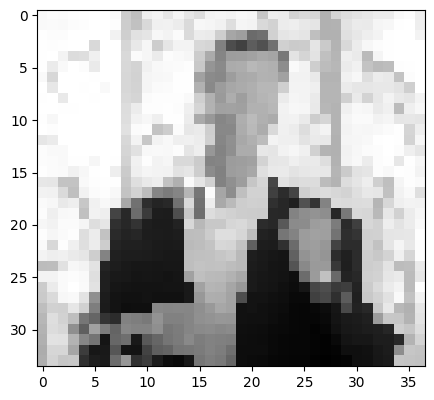

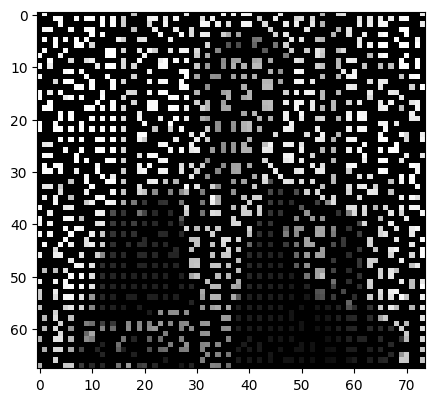

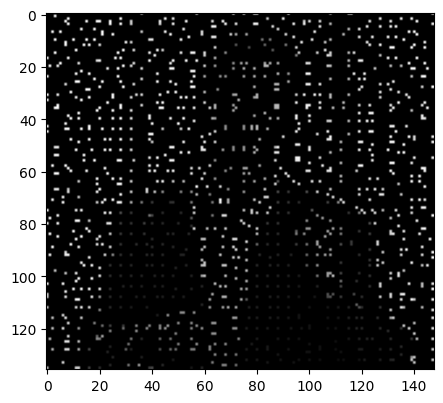

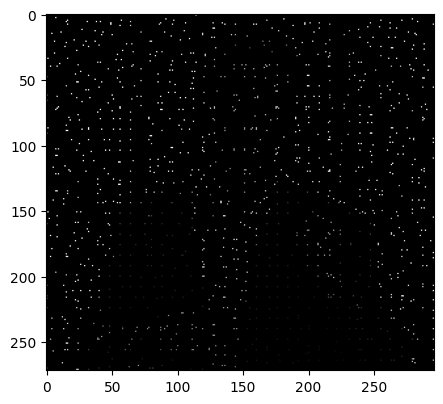

In [19]:
# Let's re-upsample, down-sampled rick
data_max_unpool= max_unpool(data_maxpool3,data_maxpool2);

plt.figure(figsize=(5,5))
plt.imshow(data_maxpool3, cmap='gray')
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(data_max_unpool, cmap='gray')
plt.show()

data_max_unpool2 = max_unpool(data_max_unpool, data_maxpool)
plt.figure(figsize=(5,5))
plt.imshow(data_max_unpool2, cmap='gray')
plt.show()

data_max_unpool3 = max_unpool(data_max_unpool2, data)
plt.figure(figsize=(5,5))
plt.imshow(data_max_unpool3, cmap='gray')
plt.show()

Finally, we'll try upsampling using bilinear interpolation.  We'll treat the positions off the image as zeros by padding the original image and round fractional values upwards using np.ceil()

In [20]:
def bilinear(x_in):
    # Output size is double the input size
    out_rows = x_in.shape[0] * 2
    out_cols = x_in.shape[1] * 2
    x_out = np.zeros((out_rows, out_cols))

    # Pad input by 1 row and 1 col for interpolation at boundaries
    x_in_pad = np.zeros((x_in.shape[0]+1, x_in.shape[1]+1))
    x_in_pad[:x_in.shape[0], :x_in.shape[1]] = x_in

    for i in range(x_in.shape[0]):
        for j in range(x_in.shape[1]):
            # top-left corner
            v00 = x_in_pad[i,j]
            # top-right
            v01 = x_in_pad[i,j+1]
            # bottom-left
            v10 = x_in_pad[i+1,j]
            # bottom-right
            v11 = x_in_pad[i+1,j+1]

            # Fill 2x2 block in output
            x_out[2*i, 2*j]     = v00
            x_out[2*i, 2*j+1]   = 0.5*(v00 + v01)
            x_out[2*i+1, 2*j]   = 0.5*(v00 + v10)
            x_out[2*i+1, 2*j+1] = 0.25*(v00 + v01 + v10 + v11)

    return x_out

In [21]:
print("Original:")
print(orig_2_2)
print("Bilinear:")
print(bilinear(orig_2_2))

Original:
[[6 8]
 [8 4]]
Bilinear:
[[6.  7.  8.  4. ]
 [7.  6.5 6.  3. ]
 [8.  6.  4.  2. ]
 [4.  3.  2.  1. ]]


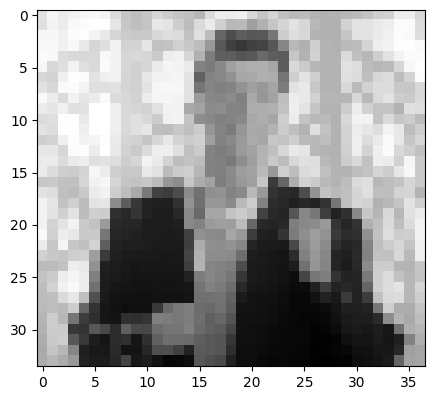

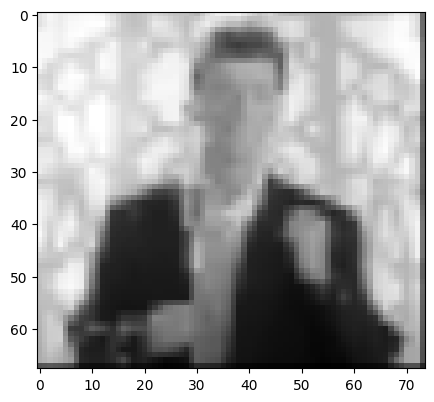

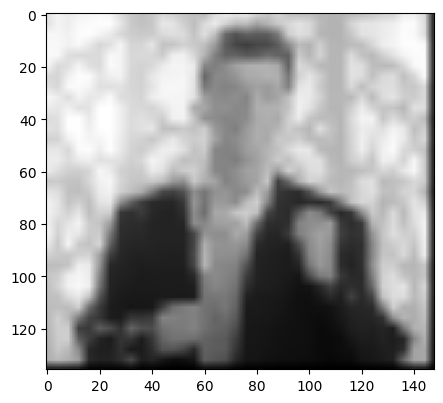

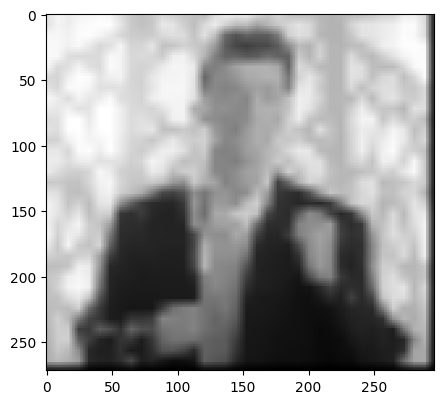

In [22]:
# Let's re-upsample, down-sampled rick
data_bilinear = bilinear(data_meanpool3);

plt.figure(figsize=(5,5))
plt.imshow(data_meanpool3, cmap='gray')
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(data_bilinear, cmap='gray')
plt.show()

data_bilinear2 = bilinear(data_bilinear)
plt.figure(figsize=(5,5))
plt.imshow(data_bilinear2, cmap='gray')
plt.show()

data_bilinear3 = duplicate(data_bilinear2)
plt.figure(figsize=(5,5))
plt.imshow(data_bilinear3, cmap='gray')
plt.show()